In [87]:
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
import copy
import math
import numpy as np
from torchvision import datasets, transforms
import torch
from numpy import *

from utils.sampling import mnist_iid_cluster, mnist_noniid_cluster, cifar_iid,cifar_noniid_cluster, cifar_noniid_cluster_varying_users
from utils.options import args_parser
from models_v2.Update import LocalUpdate,ClusterDetect
from models_v2.Nets import MLP, CNNMnist, CNNCifar, LeNet, CNNMnist2
from models_v2.Fed import FedAvg_vectorization, FedMult, FedAvg_noscale, FedAvg_gradient2
from models_v2.Fed import FedQAvg, FedBrea, Quantization, Quantization_Finite, my_score, my_score_Finite
from models_v2.test import test_img
from scipy.linalg import null_space


%load_ext autoreload
%autoreload 2
class my_argument:    
    epochs = 200   #"rounds of training"
    num_users = 5 # "number of users: K"
    frac = 0.5 #"the fraction of clients: C"
    local_ep=5 #"the number of local epochs: E"
    local_bs=125 #"local batch size: B"
    bs=128 #"test batch size"
    lr=0.0005 #"learning rate"
    momentum=0.9 # "SGD momentum (default: 0.5)"
    rho=0.9
    split='user' # "train-test split type, user or sample"

    # model arguments
    model = 'cnn'
    kernel_num=9 #, help='number of each kind of kernel')
    kernel_sizes='3,4,5' #  help='comma-separated kernel size to use for convolution')
    norm='batch_norm' #, help="batch_norm, layer_norm, or None")
    num_filters=32 #, help="number of filters for conv nets")
    max_pool='True' #help="Whether use max pooling rather than strided convolutions")

    # other arguments
    dataset='cifar' #, help="name of dataset")
    iid=0
    num_classes=10#, help="number of classes")
    num_channels=3#, help="number of channels of images")
    gpu=3#, help="GPU ID, -1 for CPU")
    stopping_rounds=10#, help='rounds of early stopping')
    verbose='False'#, help='verbose print')
    seed=1#, help='random seed (default: 1)')
    cluster=5
    opt='sgd'
    weight_decay=1e-5
args = my_argument()
#args.device = torch.device('cuda:{}'.format(args.gpu) if torch.cuda.is_available() and args.gpu != -1 else 'cpu')
print(args.epochs)
#np.random.seed(1)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
200


In [88]:
# load dataset and split users
u=[4,5,8,12,15]
u=[3,4,4,4,10]
u=[10,4,4,4,3]
#u=[5,5,5,5,5]
#u=[15,3,3,2,2]
#u=[5,5,5,5,5]
#u=[2,5,5,6,7]
#u=[2,3,4,4,12]
#u=[5,5,5,5,5]
#u=[2,2,3,3,15]
if args.dataset == 'mnist':
    trans_mnist = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    dataset_train = datasets.MNIST('./data/mnist/', train=True, download=True, transform=trans_mnist)
    dataset_test = datasets.MNIST('./data/mnist/', train=False, download=True, transform=trans_mnist)
    count=0
    #print(len(dataset_train))
    dict_users=[] #2D array in each row, users of a particular cluster
    train_data=[]
    test_data=[]
    for j in range(args.cluster):
        train_data.append([])
        test_data.append([])
        dict_users.append([])
    for j in range(len(dataset_train)):
        data,label=j
        if (label==0) | (label==1):
            train_data[0].append(dataset_train[j])
        elif (label==2) | (label==3):
            train_data[1].append(dataset_train[j])
        elif (label==4) | (label==5):
            train_data[2].append(dataset_train[j])
        elif (label==6) | (label==7):
            train_data[3].append(dataset_train[j])
        elif (label==8) | (label==9):
            train_data[4].append(dataset_train[j])
    for j in range(len(dataset_test)):
        data,label=j
        if (label==0) | (label==1):
            test_data[0].append(dataset_test[j])
        elif (label==2) | (label==3):
            test_data[1].append(dataset_test[j])
        elif (label==4) | (label==5):
            test_data[2].append(dataset_test[j])
        elif (label==6) | (label==7):
            test_data[3].append(dataset_test[j])
        elif (label==8) | (label==9):
            test_data[4].append(dataset_test[j])
    
#defining 5 different types of datasets for 5 different clusters
    
    if args.iid:
        for cluster_no in range(args.cluster):
            dict_users[cluster_no] = mnist_iid_cluster(train_data[cluster_no], args.num_users)
    else:
        for cluster_no in range(args.cluster):
            dict_users[cluster_no] = mnist_noniid_cluster(train_data[cluster_no], args.num_users)
elif args.dataset == 'cifar':
    trans_cifar = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    dataset_train = datasets.CIFAR10('./data/cifar', train=True, download=True, transform=trans_cifar)
    dataset_test = datasets.CIFAR10('./data/cifar', train=False, download=True, transform=trans_cifar)
#defining 5 different types of datasets for 5 different clusters
    count=0
    #print(len(dataset_train))
    dict_users=[] #2D array in each row, users of a particular cluster
    train_data=[]
    test_data=[]
    for j in range(args.cluster):
        train_data.append([])
        test_data.append([])
        dict_users.append([])
    for j in range(len(dataset_train)):
        data,label=dataset_train[j]
        if (label==0) | (label==1):
            train_data[0].append(dataset_train[j])
        elif (label==2) | (label==3):
            train_data[1].append(dataset_train[j])
        elif (label==4) | (label==5):
            train_data[2].append(dataset_train[j])
        elif (label==6) | (label==7):
            train_data[3].append(dataset_train[j])
        elif (label==8) | (label==9):
            train_data[4].append(dataset_train[j])
    for j in range(len(dataset_test)):
        data,label=dataset_test[j]
        if (label==0) | (label==1):
            test_data[0].append(dataset_test[j])
        elif (label==2) | (label==3):
            test_data[1].append(dataset_test[j])
        elif (label==4) | (label==5):
            test_data[2].append(dataset_test[j])
        elif (label==6) | (label==7):
            test_data[3].append(dataset_test[j])
        elif (label==8) | (label==9):
            test_data[4].append(dataset_test[j])

    if args.iid:
        for cluster_no in range(args.cluster):
            dict_users[cluster_no] = cifar_iid_cluster(train_data[cluster_no], u[cluster_no])
    else:
        for cluster_no in range(args.cluster):
            dict_users[cluster_no] = cifar_noniid_cluster_varying_users(train_data[cluster_no], u[cluster_no])
else:
    exit('Error: unrecognized dataset')
img_size = dataset_train[0][0].shape
#print(dict_users[0])
#print((dict_users[0][4]))
print(len(dataset_train))
print(len(dict_users))
print(len(train_data[0]))
#print(train_data[0])
#idxs_users = np.random.choice(range(args.num_users), m, replace=False)
#print(idxs_users)

Files already downloaded and verified
Files already downloaded and verified
50000
5
10000


In [140]:
use_cuda = torch.cuda.is_available()
#print(use_cuda)
args.device = torch.device("cuda" if use_cuda else "cpu")
#args.device=torch.device("cpu")
print(args.device)

cuda


In [183]:
acc_test=[]
acc_test_arr=[]
loss_test=[]
loss_test_arr=[]
cluster_0_acc=[]
cluster_1_acc=[]
cluster_2_acc=[]
cluster_3_acc=[]
cluster_4_acc=[]

In [184]:
# build model
from models_v2.Fed import weight_vectorization,FedSubstract,FedAvg, FedAvg_gradient,FedAdd
from models_v2.Fed import FedAdd,FedSubstract,weight_vectorization_gen,FedAvg_gradient
import numpy as np
import copy
if args.model == 'cnn' and args.dataset == 'cifar':
    net_glob=CNNCifar(args=args).to(args.device)
elif args.model == 'cnn' and args.dataset == 'mnist':
    net_glob=CNNMnist2(args=args).to(args.device)
elif args.model == 'mlp':
    len_in = 1
    for x in img_size:
        len_in *= x
    net_glob=MLP(dim_in=len_in, dim_hidden=200, dim_out=args.num_classes).to(args.device)
else:
    exit('Error: unrecognized model')
#print(net_glob)

net_glob.train()
w_glob=net_glob.state_dict()
abs_vect,layer_size=weight_vectorization_gen(w_glob)
print(len(abs_vect))
w_glob_in=copy.deepcopy(w_glob)
net_glob_in=copy.deepcopy(net_glob)

62006


In [185]:
import torch
from torch import nn, autograd
from torch.utils.data import DataLoader, Dataset

In [186]:
class DatasetSplit(Dataset):
    def __init__(self, dataset, idxs):
        self.dataset = dataset
        self.idxs = list(idxs)

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, item):
        image, label = self.dataset[self.idxs[item]]
        return image, label

In [187]:
e=np.random.uniform(1,5,1)
print(int(e))

1


In [188]:
# training
args.lr=0.0005 #0.00003
d=62006
cv_loss, cv_acc = [], []
val_loss_pre, counter = 0, 0
net_best = None
best_loss = None
val_acc_list, net_list = [], []
user_set=[]
updated=[]
prev=[]
grad_vect=[]
model_diff=[]
c_i=[]
c=np.zeros(d)
c_i_plus=[]
c_diff=[]
for i in range(25):
    user_set.append(i)
    #updated.append([])
    prev.append([])
    grad_vect.append([])
    model_diff.append([])
    #c_i.append(np.zeros(d))
    #c_i_plus.append(np.zeros(d))
    #c_diff.append(np.zeros(d))
c_diff=0
sample=0
#hist_ = np.zeros(10,dtype=int)
sample=0 # fro the purpose of using fresh samples in each iteration
total_user=25
loss_train=[]

for iter in range(1000): #args.epochs
    c_diff=0
    sum_tau=0
    if(iter>=25):
        args.lr=0.00001
    print("iteration number",iter)
    if(iter%2==0):
        sample=0
    w_locals, loss_locals = [], []
   
    cluster_block=[]
    idx_users=[]
    sorted_train_data=[]
    for cluster_no in range(args.cluster):
        for index in dict_users[cluster_no]:
            idx_users.append(index) # putting the data indices of users in this list
            sorted_train_data.append(train_data[cluster_no])#putting the corresponding training data in this array
    r=np.random.choice(user_set,5,replace=False)
    #for user2 in r:
    for user2 in range(len(idx_users)):
        net=copy.deepcopy(net_glob)
        L=600
        sample_size=int(len(idx_users[user2])/8)
        sample_size=int(L/4)
        sample_size=L
        sample_size=int(len(idx_users[user2]))
        #print(sample_size)
        ldr_train = DataLoader(DatasetSplit(sorted_train_data[user2], idx_users[user2][(sample)*sample_size:(sample+1)*sample_size]), batch_size=args.local_bs, shuffle=True)
        
        #ldr_train = DataLoader(DatasetSplit(sorted_train_data[user2], idx_users[user2]), batch_size=args.local_bs, shuffle=True)
        
        prev[user2]=copy.deepcopy(w_glob)
        prev_vector,layer_size=weight_vectorization_gen(prev[user2])
        net.train()
        global_model = copy.deepcopy(net)
        # train and update
        if args.opt == 'ADAM':
            optimizer = torch.optim.Adam(net.parameters(), lr=args.lr, weight_decay=5e-4)
        else:
            optimizer = torch.optim.SGD(net.parameters(), lr=args.lr, momentum=args.momentum, weight_decay = args.weight_decay)
        criterion = nn.CrossEntropyLoss().to(args.device)

        cnt = 0
        tau=0

    #writer = SummaryWriter()

        #c_global_para = copy.deepcopy(c_global)  #.state_dict()
        #c_local[user2] = copy.deepcopy(c_local)   #.state_dict()
        loc_ep=int(np.random.uniform(1,5,1))
        for epoch in range(loc_ep):
            epoch_loss_collector = []
            for batch_idx, (images, labels) in enumerate(ldr_train):
                #print(batch_idx)
                images, labels = images.to(args.device), labels.to(args.device)
                #x, target = x.to(device), target.to(device)

                optimizer.zero_grad()
                images.requires_grad = True
                labels.requires_grad = False
                labels = labels.long()

                out = net(images)
                loss = criterion(out, labels)

                loss.backward()
                optimizer.step()
            

                net_para = net.state_dict()
#                 for key in net_para:
#                     net_para[key] = net_para[key].to(args.device) 
#                     - args.lr * (c_global[key].to(args.device) - c_local[user2][key].to(args.device))
                net.load_state_dict(net_para)

                cnt += 1
                epoch_loss_collector.append(loss.item())
                tau = tau + 1
            #print(tau)


        epoch_loss = sum(epoch_loss_collector) / len(epoch_loss_collector)
        #logger.info('Epoch: %d Loss: %f' % (epoch, epoch_loss))
        a_i=tau
        a_i = (tau - args.rho * (1 - pow(args.rho, tau)) / (1 - args.rho)) / (1 - args.rho)
        #c_new_para = copy.deepcopy(c_local[user2])  #.state_dict()
        #c_delta_para = copy.deepcopy(c_local[user2])
        #global_model_para = copy.deepcopy(prev[user2]) #global_model.state_dict()
        net_para = net.state_dict()
#       
        w_locals.append(copy.deepcopy(net_para))
        loss_locals.append(copy.deepcopy(epoch_loss))
        #prev[user2]=copy.deepcopy(w_glob)
        model_diff[user2]=FedSubstract(net_para,prev[user2])
        grad_vect[user2],layer_size=weight_vectorization_gen(model_diff[user2])
        scale=sample_size/50000
        #scale=1/25
        #grad_vect[user2]=(scale*grad_vect[user2]/tau)
        grad_vect[user2]=(scale*grad_vect[user2]/a_i)
        #sum_tau=sum_tau+scale*tau
        sum_tau=sum_tau+scale*a_i
        
        #w=FedMult(w,scale)   
    grad_avg=FedAvg_gradient2(grad_vect)
    grad_avg=grad_avg*sum_tau #/total_user
    #c_diff=FedAvg(c_delta_para)
    #c_global=FedAdd(c_global,c_diff)
    #control_avg=FedAvg_gradient(c_diff)
    #control_avg=c_diff/25
    w_glob_prev=copy.deepcopy(w_glob)
    flat=[]
    for i in range(len(w_glob.keys())): # 4 layers in parameter
        flat.append([])
    count=0
    for h in w_glob_prev.keys():
        s=list(w_glob[h].shape)
        if (len(s)==0):
            new=np.array(0)
            grad_avg=np.delete(grad_avg,np.s_[0])
        else:
            z=np.prod(list(w_glob[h].shape))
            flat[count]=grad_avg[0:z] # taking out the vector for the specified layer
            grad_avg=np.delete(grad_avg,np.s_[0:z])# deleting that vector from decoded after taking out
             
            new=flat[count].reshape(list(w_glob[h].shape)) #reshaping back to the marix
              
        w_glob[h]=torch.from_numpy(new) #converting the matrix to a tensor
            #print(w_glob[cluster_no][h].shape)
        count=count+1
    # update global weights
        
    global_diff = w_glob
    w_glob=FedAdd(w_glob_prev,global_diff)
    net_glob.load_state_dict(w_glob)
        
    #w_glob = FedAvg(w_locals)
    # copy weight to net_glob
    net_glob.load_state_dict(w_glob)
    #c_global=FedAdd(c_global)
     # print loss
    loss_avg = sum(loss_locals) / len(loss_locals)
    
    loss_train.append(loss_avg)
    
    acc_test, loss_test = test_img(net_glob, dataset_test, args)
    acc_test_arr.append(acc_test)
    loss_test_arr.append(loss_test)
    if iter % 1 ==0:
        print('Round {:3d}, Average loss {:.3f} Test accuracy {:.3f}'.format(iter, loss_avg,acc_test))
        #print(hist_)
    #print(loss_train)
    acc_test,loss_test=test_img(net_glob,test_data[0],args)
    cluster_0_acc.append(acc_test)
    print("cluster 0")
    print(acc_test)
    acc_test,loss_test=test_img(net_glob,test_data[1],args)
    cluster_1_acc.append(acc_test)
    print("cluster 1")
    print(acc_test)
    acc_test,loss_test=test_img(net_glob,test_data[2],args)
    cluster_2_acc.append(acc_test)
    print("cluster 2")
    print(acc_test)
    acc_test,loss_test=test_img(net_glob,test_data[3],args)
    cluster_3_acc.append(acc_test)
    print("cluster 3")
    print(acc_test)
    acc_test,loss_test=test_img(net_glob,test_data[4],args)
    cluster_4_acc.append(acc_test)
    print("cluster 4")
    print(acc_test)
    #sample=sample+1
   
    
           

iteration number 0
Round   0, Average loss 2.275 Test accuracy 10.000
cluster 0
tensor(0.)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(50.)
cluster 4
tensor(0.)
iteration number 1
Round   1, Average loss 2.269 Test accuracy 10.000
cluster 0
tensor(0.)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(50.)
cluster 4
tensor(0.)
iteration number 2
Round   2, Average loss 2.272 Test accuracy 10.000
cluster 0
tensor(0.)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(50.)
cluster 4
tensor(0.)
iteration number 3
Round   3, Average loss 2.269 Test accuracy 10.000
cluster 0
tensor(0.)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(50.)
cluster 4
tensor(0.)
iteration number 4
Round   4, Average loss 2.267 Test accuracy 10.000
cluster 0
tensor(0.)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(50.)
cluster 4
tensor(0.)
iteration number 5
Round   5, Average loss 2.267 Test accuracy 10.000
cluster 0
tensor(0.)
cluster 1
tensor(0.)
cluster 

Round  46, Average loss 2.261 Test accuracy 11.800
cluster 0
tensor(59.)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 47
Round  47, Average loss 2.261 Test accuracy 11.800
cluster 0
tensor(59.)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 48
Round  48, Average loss 2.261 Test accuracy 11.790
cluster 0
tensor(58.9500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 49
Round  49, Average loss 2.261 Test accuracy 11.790
cluster 0
tensor(58.9500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 50
Round  50, Average loss 2.260 Test accuracy 11.800
cluster 0
tensor(59.)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 51
Round  51, Average loss 2.261 Test accuracy 11.800
cluster 0
tensor(59.)
cluster 1
tensor(0.)
cluster 2
ten

Round  92, Average loss 2.260 Test accuracy 11.780
cluster 0
tensor(58.9000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 93
Round  93, Average loss 2.260 Test accuracy 11.780
cluster 0
tensor(58.9000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 94
Round  94, Average loss 2.260 Test accuracy 11.770
cluster 0
tensor(58.8500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 95
Round  95, Average loss 2.260 Test accuracy 11.770
cluster 0
tensor(58.8500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 96
Round  96, Average loss 2.260 Test accuracy 11.770
cluster 0
tensor(58.8500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 97
Round  97, Average loss 2.260 Test accuracy 11.770
cluster 0
tensor(58.8500)
cluster 1
tensor(0

Round 138, Average loss 2.259 Test accuracy 11.820
cluster 0
tensor(59.1000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 139
Round 139, Average loss 2.259 Test accuracy 11.820
cluster 0
tensor(59.1000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 140
Round 140, Average loss 2.259 Test accuracy 11.820
cluster 0
tensor(59.1000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 141
Round 141, Average loss 2.259 Test accuracy 11.810
cluster 0
tensor(59.0500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 142
Round 142, Average loss 2.259 Test accuracy 11.820
cluster 0
tensor(59.1000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 143
Round 143, Average loss 2.259 Test accuracy 11.820
cluster 0
tensor(59.1000)
cluster 1
ten

Round 184, Average loss 2.258 Test accuracy 11.940
cluster 0
tensor(59.7000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 185
Round 185, Average loss 2.258 Test accuracy 11.950
cluster 0
tensor(59.7500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 186
Round 186, Average loss 2.258 Test accuracy 11.950
cluster 0
tensor(59.7500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 187
Round 187, Average loss 2.258 Test accuracy 11.960
cluster 0
tensor(59.8000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 188
Round 188, Average loss 2.258 Test accuracy 11.950
cluster 0
tensor(59.7500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 189
Round 189, Average loss 2.258 Test accuracy 11.970
cluster 0
tensor(59.8500)
cluster 1
ten

...

Round 276, Average loss 2.257 Test accuracy 12.130
cluster 0
tensor(60.6500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 277
Round 277, Average loss 2.257 Test accuracy 12.130
cluster 0
tensor(60.6500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 278
Round 278, Average loss 2.257 Test accuracy 12.120
cluster 0
tensor(60.6000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 279
Round 279, Average loss 2.257 Test accuracy 12.100
cluster 0
tensor(60.5000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 280
Round 280, Average loss 2.257 Test accuracy 12.100
cluster 0
tensor(60.5000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 281
Round 281, Average loss 2.257 Test accuracy 12.100
cluster 0
tensor(60.5000)
cluster 1
ten

Round 322, Average loss 2.256 Test accuracy 12.170
cluster 0
tensor(60.8500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 323
Round 323, Average loss 2.256 Test accuracy 12.170
cluster 0
tensor(60.8500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 324
Round 324, Average loss 2.256 Test accuracy 12.180
cluster 0
tensor(60.9000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 325
Round 325, Average loss 2.256 Test accuracy 12.180
cluster 0
tensor(60.9000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 326
Round 326, Average loss 2.256 Test accuracy 12.180
cluster 0
tensor(60.9000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 327
Round 327, Average loss 2.256 Test accuracy 12.190
cluster 0
tensor(60.9500)
cluster 1
ten

Round 368, Average loss 2.255 Test accuracy 12.320
cluster 0
tensor(61.6000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 369
Round 369, Average loss 2.255 Test accuracy 12.310
cluster 0
tensor(61.5500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 370
Round 370, Average loss 2.255 Test accuracy 12.310
cluster 0
tensor(61.5500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 371
Round 371, Average loss 2.255 Test accuracy 12.300
cluster 0
tensor(61.5000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 372
Round 372, Average loss 2.255 Test accuracy 12.290
cluster 0
tensor(61.4500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 373
Round 373, Average loss 2.255 Test accuracy 12.300
cluster 0
tensor(61.5000)
cluster 1
ten

Round 414, Average loss 2.254 Test accuracy 12.310
cluster 0
tensor(61.5500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 415
Round 415, Average loss 2.254 Test accuracy 12.300
cluster 0
tensor(61.5000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 416
Round 416, Average loss 2.254 Test accuracy 12.300
cluster 0
tensor(61.5000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 417
Round 417, Average loss 2.254 Test accuracy 12.290
cluster 0
tensor(61.4500)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 418
Round 418, Average loss 2.254 Test accuracy 12.280
cluster 0
tensor(61.4000)
cluster 1
tensor(0.)
cluster 2
tensor(0.)
cluster 3
tensor(0.)
cluster 4
tensor(0.)
iteration number 419
Round 419, Average loss 2.254 Test accuracy 12.300
cluster 0
tensor(61.5000)
cluster 1
ten

KeyboardInterrupt: 

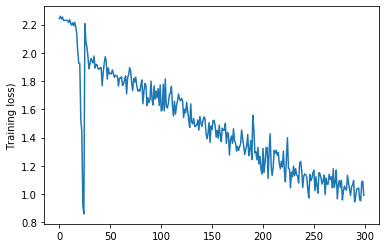

In [178]:
plt.plot(range(len(loss_train[0:300])), loss_train[0:300])
plt.ylabel('Training loss)')
plt.show()

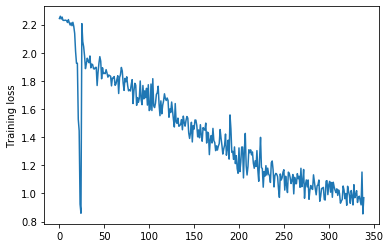

In [179]:
plt.plot(range(len(loss_train[0:500])), loss_train[0:500])
plt.ylabel('Training loss')
plt.show()
#print(loss_train)

In [ ]:
print(args.local_ep)
print(prev_vector)

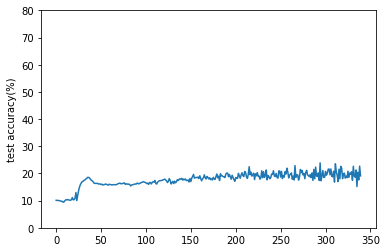

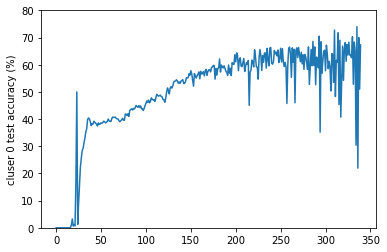

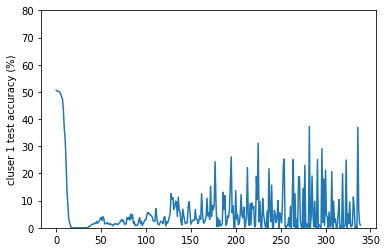

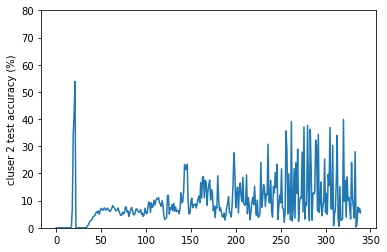

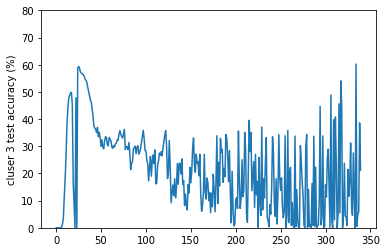

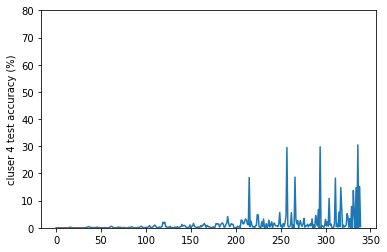

In [180]:
step=500
plt.ylim(0,80)
plt.plot(range(len(acc_test_arr[0:step])), acc_test_arr[0:step])
plt.ylabel('test accuracy(%)')
plt.show()
plt.ylim(0,80)
plt.plot(range(len(cluster_0_acc[0:step])), cluster_0_acc[0:step])
plt.ylabel('cluser 0 test accuracy (%)')
plt.show()
plt.ylim(0,80)
plt.plot(range(len(cluster_1_acc[0:step])), cluster_1_acc[0:step])
plt.ylabel('cluser 1 test accuracy (%)')
plt.show()
plt.ylim(0,80)
plt.plot(range(len(cluster_2_acc[0:step])), cluster_2_acc[0:step])
plt.ylabel('cluser 2 test accuracy (%)')
plt.show()
plt.ylim(0,80)
plt.plot(range(len(cluster_3_acc[0:step])), cluster_3_acc[0:step])
plt.ylabel('cluser 3 test accuracy (%)')
plt.show()
plt.ylim(0,80)
plt.plot(range(len(cluster_4_acc[0:step])), cluster_4_acc[0:step])
plt.ylabel('cluser 4 test accuracy (%)')
plt.show()

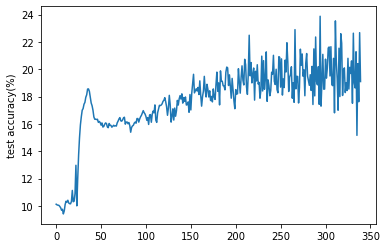

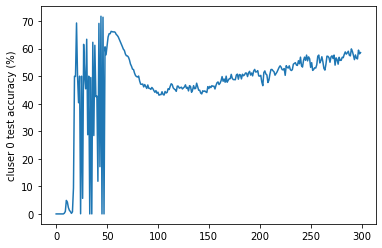

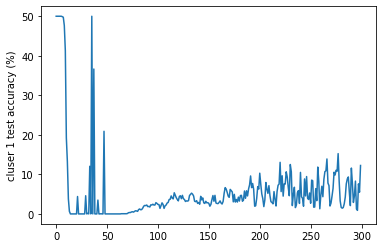

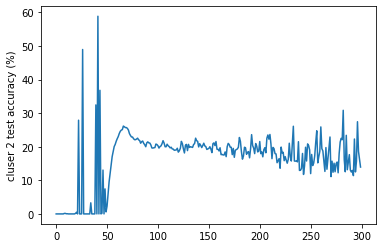

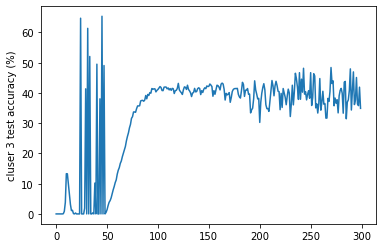

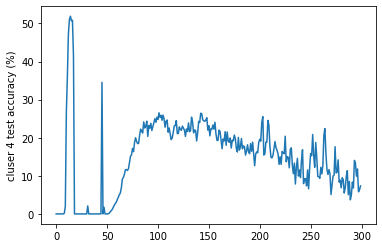

In [182]:
plt.plot(range(len(acc_test_arr)), acc_test_arr)
plt.ylabel('test accuracy(%)')
plt.show()
plt.plot(range(len(cluster_0)), cluster_0)
plt.ylabel('cluser 0 test accuracy (%)')
plt.show()
plt.plot(range(len(cluster_1)), cluster_1)
plt.ylabel('cluser 1 test accuracy (%)')
plt.show()
plt.plot(range(len(cluster_2)), cluster_2)
plt.ylabel('cluser 2 test accuracy (%)')
plt.show()
plt.plot(range(len(cluster_3)), cluster_3)
plt.ylabel('cluser 3 test accuracy (%)')
plt.show()
plt.plot(range(len(cluster_4)), cluster_4)
plt.ylabel('cluser 4 test accuracy (%)')
plt.show()

In [171]:
cluster_0=[]
cluster_1=[]
cluster_2=[]
cluster_3=[]
cluster_4=[]
acc_test=[]
for i in range(300):
    cluster_0.append(float(cluster_0_acc[i]))
    cluster_1.append(float(cluster_1_acc[i]))
    cluster_2.append(float(cluster_2_acc[i]))
    cluster_3.append(float(cluster_3_acc[i]))
    cluster_4.append(float(cluster_4_acc[i]))
    acc_test.append(float(acc_test_arr[i]))
print(cluster_0)
print(cluster_1)
print(cluster_2)
print(cluster_3)
print(cluster_4)
#print(acc_test)

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.8999999761581421, 4.900000095367432, 4.300000190734863, 2.299999952316284, 1.2999999523162842, 0.8500000238418579, 0.20000000298023224, 0.75, 9.399999618530273, 49.95000076293945, 49.900001525878906, 69.30000305175781, 49.849998474121094, 40.349998474121094, 50.0, 0.05000000074505806, 50.0, 5.650000095367432, 61.54999923706055, 49.79999923706055, 45.400001525878906, 63.400001525878906, 28.75, 50.0, 0.0, 49.5, 0.0, 62.29999923706055, 28.450000762939453, 61.20000076293945, 42.54999923706055, 42.79999923706055, 11.850000381469727, 69.1500015258789, 17.149999618530273, 71.75, 0.0, 71.4000015258789, 0.0, 60.650001525878906, 57.75, 61.099998474121094, 64.19999694824219, 65.4000015258789, 65.4000015258789, 66.25, 66.1500015258789, 66.05000305175781, 66.0999984741211, 65.9000015258789, 65.1500015258789, 64.80000305175781, 64.25, 63.400001525878906, 62.54999923706055, 61.79999923706055, 60.75, 59.79999923706055, 59.349998474121094, 58.04999923706

In [ ]:
print(sum(cluster_0))
print(sum(cluster_1))
print(sum(cluster_2))
print(sum(cluster_3))
print(sum(cluster_4))